In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter


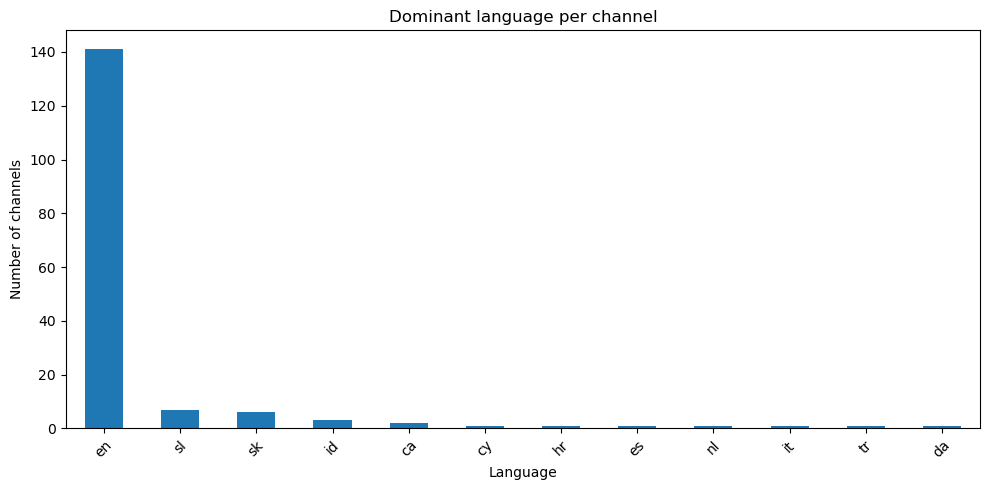

In [2]:

df_preprocessed_non_empty_channels = pd.read_csv(
    "../../results/levels/level_0/preProcessing/preprocessed_messages_level_0.tsv.gz", 
    sep='\t', 
    compression='gzip'
)

df_english_preprocessed_non_empty_channels = pd.read_csv(
    "../../results/levels/level_0/preProcessing/preprocessed_english_messages_level_0.tsv.gz", 
    sep='\t', 
    compression='gzip'
)

# Group by channel_id and language, count the number of messages
lang_counts = df_preprocessed_non_empty_channels.groupby(['channel_id', 'language']).size().reset_index(name='count')

# Sort by channel_id and message count in descending order
lang_counts_sorted = lang_counts.sort_values(['channel_id', 'count'], ascending=[True, False])

# Keep only the most frequent language for each channel
dominant_lang = lang_counts_sorted.drop_duplicates(subset='channel_id', keep='first')

# Plot the distribution of dominant languages
plt.figure(figsize=(10, 5))
dominant_lang['language'].value_counts().plot(kind='bar')
plt.title("Dominant language per channel")
plt.xlabel("Language")
plt.ylabel("Number of channels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Index(['text', 'timestamp', 'llm_txt_preprocessed', 'text_preprocessed',
       'llm_text_preprocessed', 'language', 'channel_id'],
      dtype='object')


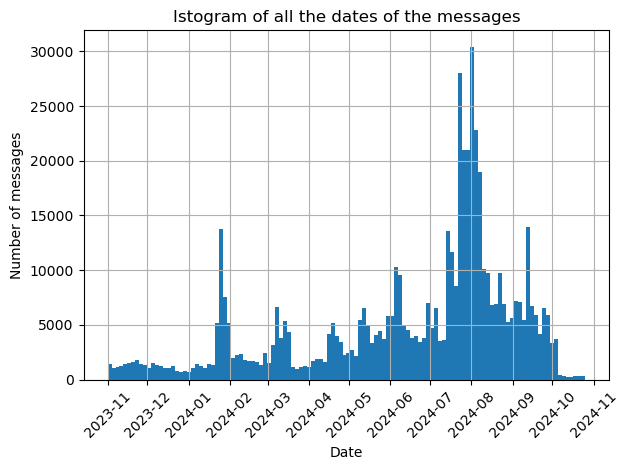

Numero di testi pre-processati: 570427
---
Numero di canali unici: 156
---


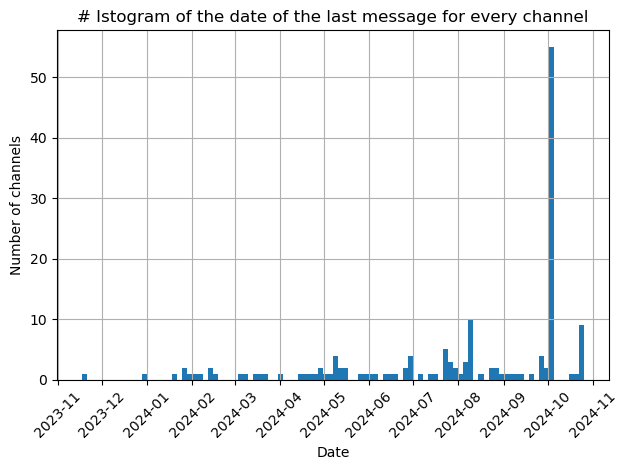

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter

# Conversione timestamp da secondi a datetime
df_english_preprocessed_non_empty_channels['timestamp'] = pd.to_datetime(
    df_english_preprocessed_non_empty_channels['timestamp'],
    unit='s'
)

# Istogram of all the dates of the messages
print(df_english_preprocessed_non_empty_channels.columns)

df_english_preprocessed_non_empty_channels['timestamp'].hist(bins=120)

ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator(interval=1))          # tick ogni 1 mese
ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))          # formato anno-mese

plt.title("Istogram of all the dates of the messages")
plt.xlabel("Date")
plt.ylabel("Number of messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Numero di testi pre-processati:", len(df_english_preprocessed_non_empty_channels['text_preprocessed']))
print("---")
print("Numero di canali unici:", df_english_preprocessed_non_empty_channels['channel_id'].nunique())
print("---")

# Istogram of the date of the last message for every channel
last_timestamps = (
    df_english_preprocessed_non_empty_channels
    .sort_values(by='timestamp')
    .drop_duplicates(subset='channel_id', keep='last')['timestamp']
)

last_timestamps.hist(bins=100)

ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator(interval=1))          # tick ogni 1 mese
ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))          # formato anno-mese

plt.title("# Istogram of the date of the last message for every channel")
plt.xlabel("Date")
plt.ylabel("Number of channels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
